In [1]:
import torch 
import os
import torch.optim
import torch.nn as nn
import torchvision.datasets as dset
from torch.utils.data import dataloader
from torchvision.transforms import transforms
import torchvision.utils as vutils
import numpy as np 
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from timeit import default_timer as timer
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

2.10.0+cu128
True
12.8


In [4]:
#Custom anime datasetclass
from torch.utils.data import Dataset
from PIL import Image
import os 

class anime_dataset(Dataset):
    def __init__(self, root , transforms=None):
        self.root = root
        self.image = os.listdir(root)
        self.transforms = transforms

    def __len__(self):
        return(len(self.image))

    def __getitem__(self, idx):
       img_path = os.path.join(self.root, self.image[idx])
       img = Image.open(img_path).convert('RGB')
       if self.transforms:
           img = self.transforms(img)
       return img 

In [5]:
#transform

data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))
])

In [6]:
#dataste and dataloader
data_root = '/kaggle/input/datasets/splcher/animefacedataset/images'
anime_data = anime_dataset(root=data_root, transforms=data_transforms)

anime_dataloader = torch.utils.data.DataLoader(anime_data,
                                               batch_size=64,
                                               shuffle=True,
                                               pin_memory=True,
                                               drop_last=True)

print(f'Total Lenght of dataset:{len(anime_data)}')
print(f'Total lenght of dataloader:{len(anime_dataloader)} ')

Total Lenght of dataset:63565
Total lenght of dataloader:993 


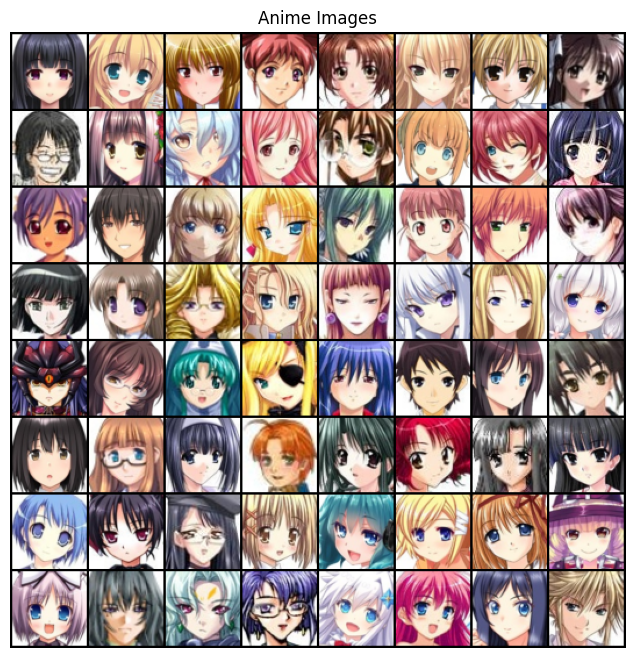

In [7]:
#visualizing dataset
batch = next(iter(anime_dataloader))
plt.figure(figsize=(8,8))
plt.axis('off')
plt.title('Anime Images')
plt.imshow(np.transpose(vutils.make_grid(batch[:64], padding=2, normalize=True).cpu(), (1,2,0)))
plt.show()


In [8]:
#variance schedule
T = 1000
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end , steps=T)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

In [9]:
#forward pass 
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_alphas_cumprod_t = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alphas_cumprod_t = torch.sqrt(1. - alphas_cumprod[t]).view(-1,1,1,1)

    return sqrt_alphas_cumprod_t * x0 + sqrt_one_minus_alphas_cumprod_t*noise

In [10]:
#device 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device 

'cuda'

In [11]:
alphas_cumprod = alphas_cumprod.to(device)

In [12]:
#SinusoidalPositionEmbeddings
import math
import torch.nn as nn 

class SinusoidalPositionEmbeddings(torch.nn.Module):
    def __init__(self, dim:int):
        super().__init__()
        assert dim % 2 == 0, "Embedding must divisble by 2"
        self.dim = dim 
    
    def forward(self, time_stamps: torch.Tensor) -> torch.Tensor :
        device = time_stamps.device
        half_dim = self.dim // 2
        scale = math.log(10000)/ (half_dim - 1)
        freqs= torch.exp(torch.arange(half_dim, dtype=torch.float32, device=device) * -scale)
        embeddings = time_stamps[:, None].float() * freqs[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings 
        

In [13]:
#time embedding 

class Time_embeddings(torch.nn.Module):
    def __init__(self, time_emb_dim: int, out_dim: int):
        super().__init__()
        self.sinusoidal_emb = SinusoidalPositionEmbeddings(time_emb_dim)

        self.mlp = nn.Sequential(
            nn.Linear(time_emb_dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim)
        )
    def forward (self, time_steps: torch.Tensor) -> torch.Tensor :
        raw_emb = self.sinusoidal_emb(time_steps)
        return self.mlp(raw_emb)

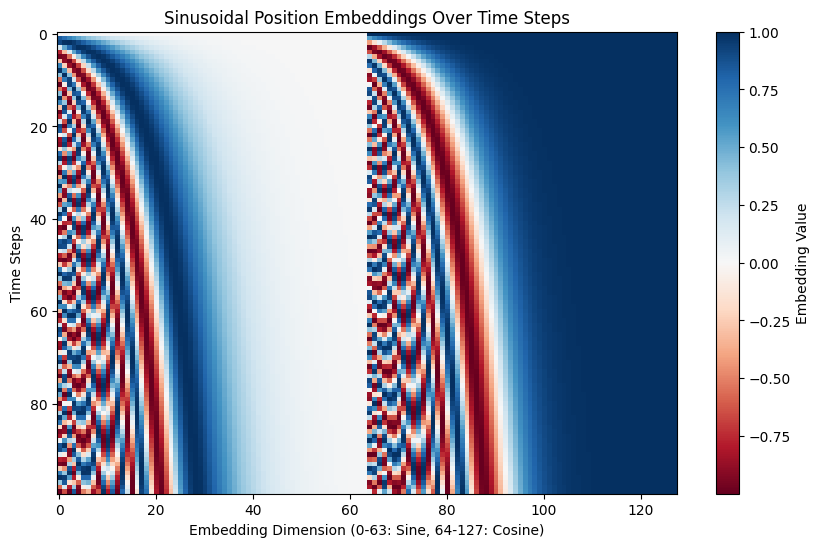

In [14]:
# 1. Instantiate the embedding layer with 128 dimensions
embedding_dim = 128
pos_embedding = SinusoidalPositionEmbeddings(dim=embedding_dim)

# 2. Create a batch of 100 chronological time steps (0 to 99)
time_stamps = torch.arange(100)

# 3. Generate the embeddings (Output shape will be)
embeddings = pos_embedding(time_stamps)

# 4. Plot the resulting matrix as a heatmap
plt.figure(figsize=(10, 6))
plt.imshow(embeddings.numpy(), cmap="RdBu", aspect="auto")
plt.colorbar(label="Embedding Value")
plt.title("Sinusoidal Position Embeddings Over Time Steps")
plt.xlabel("Embedding Dimension (0-63: Sine, 64-127: Cosine)")
plt.ylabel("Time Steps")
plt.show()

In [15]:
#Resblock 

class ResBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.act = nn.SiLU()
        self.time_mlp = nn.Linear(time_emb_dim, out_channels)
        #Matches in_channels and out_channels for skip connections 
        self.residual_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, time_emb):
        h = self.norm1(self.conv1(x))
        h = self.act(h)
        # inject time embedding — shape (B, out_channels) → (B, out_channels, 1, 1)
        time_proj = self.act(self.time_mlp(time_emb))[:, :, None, None]
        h = h + time_proj 
        h = self.norm2(self.conv2(h))
        h = self.act(h)
        return h + self.residual_conv(x)


In [16]:
#downsample and upsample 

class Down_sample(torch.nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 4, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

class Up_sample(torch.nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.ConvTranspose2d(channels, channels, 4, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

In [17]:
#Full Unet class 

class Unet(nn.Module):
    def __init__(self, in_channels=3, time_emb_dim=128):
        super().__init__()
        # time embedding outputs 256-dim vector
        self.time_embeddings = Time_embeddings(time_emb_dim, out_dim=256)

        self.inc = nn.Conv2d(in_channels, 64, 3, padding=1)

        # Encoder
        self.down1 = ResBlock(64, 128, time_emb_dim=256)
        self.down_sample1 = Down_sample(128)

        self.down2 = ResBlock(128, 256, time_emb_dim=256)
        self.down_sample2 = Down_sample(256)

        # Bottleneck
        self.bot1 = ResBlock(256, 256, time_emb_dim=256)
        self.bot2 = ResBlock(256, 256, time_emb_dim=256)

        # Decoder (input channels doubled due to skip connection concat)
        self.up_sample1 = Up_sample(256)
        self.up1 = ResBlock(512, 128, time_emb_dim=256)   # 256 + 256 = 512

        self.up_sample2 = Up_sample(128)
        self.up2 = ResBlock(256, 64, time_emb_dim=256)    # 128 + 128 = 256

        self.outc = nn.Conv2d(64, in_channels, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_embeddings(t)      # (B,) → (B, 256)

        # Encoder
        x1 = self.inc(x)                    # (B, 64, 64, 64)
        x2 = self.down1(x1, t_emb)          # (B, 128, 64, 64)
        x3 = self.down_sample1(x2)          # (B, 128, 32, 32)
        x4 = self.down2(x3, t_emb)          # (B, 256, 32, 32)
        x5 = self.down_sample2(x4)          # (B, 256, 16, 16)

        # Bottleneck
        x5 = self.bot1(x5, t_emb)           # (B, 256, 16, 16)
        x5 = self.bot2(x5, t_emb)           # (B, 256, 16, 16)

        # Decoder
        x6 = self.up_sample1(x5)            # (B, 256, 32, 32)
        x6 = torch.cat([x6, x4], dim=1)     # (B, 512, 32, 32) — skip from x4
        x6 = self.up1(x6, t_emb)            # (B, 128, 32, 32)

        x7 = self.up_sample2(x6)            # (B, 128, 64, 64)
        x7 = torch.cat([x7, x2], dim=1)     # (B, 256, 64, 64) — skip from x2
        x7 = self.up2(x7, t_emb)            # (B, 64, 64, 64)

        return self.outc(x7)                 # (B, 3, 64, 64)
        

In [18]:
from torchinfo import summary

model = Unet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()
summary(model)

Layer (type:depth-idx)                        Param #
Unet                                          --
├─Time_embeddings: 1-1                        --
│    └─SinusoidalPositionEmbeddings: 2-1      --
│    └─Sequential: 2-2                        --
│    │    └─Linear: 3-1                       33,024
│    │    └─SiLU: 3-2                         --
│    │    └─Linear: 3-3                       65,792
├─Conv2d: 1-2                                 1,792
├─ResBlock: 1-3                               --
│    └─Conv2d: 2-3                            73,856
│    └─Conv2d: 2-4                            147,584
│    └─GroupNorm: 2-5                         256
│    └─GroupNorm: 2-6                         256
│    └─SiLU: 2-7                              --
│    └─Linear: 2-8                            32,896
│    └─Conv2d: 2-9                            8,320
├─Down_sample: 1-4                            --
│    └─Conv2d: 2-10                           262,272
├─ResBlock: 1-5               

In [19]:
#EMA 

class EMA():
    def __init__(self ,model ,decay=0.9999):
        self.model = model
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        
    def register(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()
                
    def update(self):
        for name , param in self.model.named_parameters():
            if param.requires_grad:
                assert name in self.shadow
                new_avg  = self.decay*self.shadow[name] + (1. - self.decay)*param.data
                self.shadow[name] = new_avg.clone()
                
    def apply_shadow(self):
        for name , param in self.model.named_parameters():
            if param.requires_grad:
                assert name in self.shadow
                self.backup[name] = param.data.clone()
                param.data.copy_(self.shadow[name])

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                assert name in self.backup
                param.data.copy_(self.backup[name])
        self.backup = {}

In [20]:
#Function to move optimizer state and weights to device 
def optimizer_to_device(optimizer:torch.optim.Optimizer, device:torch.device):
    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance( v, torch.Tensor):
                state[k] = v.to(device)

In [21]:
#loading checkpiont 

checkpoint = torch.load('/kaggle/input/models/adityachaubeycode/ddpmv4/pytorch/default/1/best_checkpoint4(1).pth', map_location=device)
print(checkpoint.keys())        
print(checkpoint['epoch'])      
print(checkpoint['loss']) 

#loading ema_shadow weights 
ema = EMA(model , decay=0.9999)
ema.register()
ema.shadow = checkpoint['ema_shadow']

#loading state_dict
model.load_state_dict(checkpoint['model_state_dict'])

#loading optimizer state dict 
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
optimizer_to_device(optimizer=optimizer, device=device)

start_epoch = 0
start_epoch = checkpoint['epoch'] +1
best_loss = checkpoint['loss']

print(f'EMA shadow weights loaded {len(ema.shadow)}')

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'ema_shadow', 'loss'])
40
0.023728408923884715
EMA shadow weights loaded 84


In [22]:
#Total time
def total_train_time(start:float, end:float, device:torch.device):
    total_time = end - start
    min = int(total_time //  60)
    sec = total_time%60
    print(f" Total time spend on device:{device} is {min}minutes and {sec:.2f}seconds")
    return total_time

In [23]:
torch.cuda.empty_cache()
print(f'GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB')
print(f'GPU memory reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB')

GPU memory allocated: 0.15 GB
GPU memory reserved: 0.16 GB


In [24]:
# confirm these are all set before starting
print(next(model.parameters()).device)  # should be cuda
print(alphas_cumprod.device)            # should be cuda, if not: alphas_cumprod = alphas_cumprod.to(device)
print(len(anime_dataloader))            # sanity check dataloader works

cuda:0
cuda:0
993


In [25]:
#Full training loop '

from torch.cuda.amp import GradScaler, autocast 

scaler = torch.amp.GradScaler('cuda')
epochs = 10
start_epoch = checkpoint['epoch'] +1
best_loss = checkpoint['loss']
loss_history=[]
start_time = timer()

ema = EMA(model, decay=0.9999)
ema.register()

for epoch in tqdm(range(start_epoch, start_epoch + epochs)):
    print(f'{epoch+1}/{epochs}\n-----')
    model.train()
    train_loss = 0 

    for batch_idx,img in enumerate(anime_dataloader):
        
        img = img.to(device)
        t = torch.randint(0, T, (img.shape[0],), device=device)
        noise = torch.randn_like(img).to(device)
        xt = q_sample(x0=img, t=t, noise=noise)
        
        with torch.autocast('cuda'):
            output = model(xt, t)
            loss = loss_fn(output, noise)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        ema.update()
        scaler.update()
        optimizer.zero_grad()
        train_loss += loss.item()
        
    train_loss = train_loss / len(anime_dataloader)
    loss_history.append(train_loss)
    print(f' Avg loss :{train_loss:.4f}')
    
    if train_loss < best_loss:
        best_loss = train_loss
        torch.save({
            'epoch':epoch+1,
            'model_state_dict':model.state_dict(),
            'optimizer_state_dict':optimizer.state_dict(),
            'loss':best_loss,
        }, '/kaggle/working/best_checkpoint3.pth')
        torch.save({
            'ema_shadow':ema.shadow
        }, '/kaggle/working/ema_shadow.pth')
        print(f' Model saved at epoch :{epoch} | Current best loss:{best_loss:.4f}')

end_time = timer()
print_total_time = total_train_time(start=start_time, end=end_time, device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

42/10
-----
 Avg loss :0.0239
43/10
-----
 Avg loss :0.0240
44/10
-----
 Avg loss :0.0234
 Model saved at epoch :43 | Current best loss:0.0234
45/10
-----
 Avg loss :0.0236
46/10
-----
 Avg loss :0.0237
47/10
-----
 Avg loss :0.0235
48/10
-----
 Avg loss :0.0237
49/10
-----
 Avg loss :0.0233
 Model saved at epoch :48 | Current best loss:0.0233
50/10
-----
 Avg loss :0.0239
51/10
-----
 Avg loss :0.0235
 Total time spend on device:cuda is 56minutes and 35.00seconds


In [36]:
#Sampling loop 
sqrt_recip_alphas = torch.sqrt(1.0 / alphas).to(device)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod).to(device)
posterior_variance = betas.to(device)

@torch.no_grad()
def sample_ddim(model, T,img_size,  batch_size=16, channels=3,ddim_step=50):
    model.eval()
    
    timestep = torch.linspace(0, T-1, steps=ddim_step, dtype=torch.long, device=device)
    img = torch.randn(batch_size, channels, img_size, img_size).to(device)
    
    for i in reversed(range(len(timestep))):
        t_current =timestep[i]
        t_preq = timestep[i-1] if i > 0 else -1
        t_tensor = torch.full((batch_size,), t_current, dtype=torch.long, device=device)
        
        pred_noise = model(img , t_tensor)
        alphas_bar_t = alphas_cumprod[t_current]
        alphas_bar_t_preq = alphas_cumprod[t_preq] if t_preq >= 0 else torch.tensor(1.0, device=device)
        pred_x0 = (img - torch.sqrt(1 - alphas_bar_t) * pred_noise)/(torch.sqrt(alphas_bar_t))
        pred_x0 = torch.clamp(pred_x0, -1.0, 1.0)
        pred_dir = torch.sqrt(1 - alphas_bar_t_preq) * pred_noise
        img = torch.sqrt(alphas_bar_t_preq) * pred_x0 + pred_dir
        
    return img 
        
    

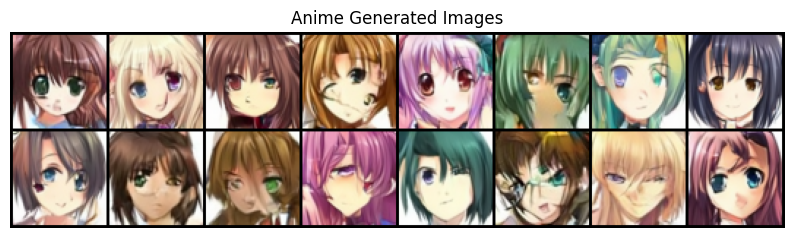

In [42]:
#Images generated by the model 
ema.apply_shadow()
generate = sample_ddim(model ,T=T ,img_size=64, batch_size=16)
ema.restore()
generate = (generate.clamp(-1,1) +1)/2

plt.figure(figsize=(10,10))
plt.axis('off')
plt.title('Anime Generated Images')
plt.imshow(np.transpose(vutils.make_grid(generate.cpu(), padding=2, normalize=True).numpy(), (1,2,0)))
plt.show()

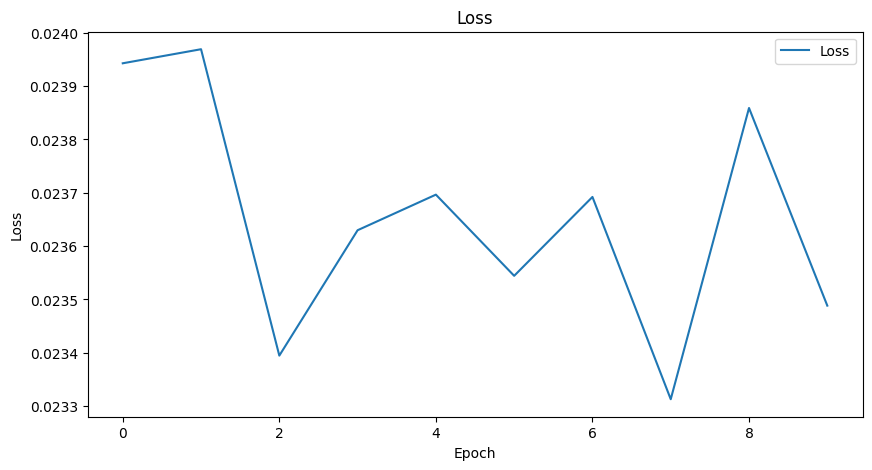

In [38]:
plt.figure(figsize=(10,5))
plt.title('Loss')
plt.plot(loss_history,label='Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()